Step 1: Upload Dataset in Google Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv
Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020 (1).csv


Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Step 3: Load Dataset

In [3]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Step 4: Basic Information

In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


Step 5: Clean Dataset

In [5]:
df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [7]:
df = df.dropna()

print(df.shape)

(740, 7)


Step 6: Convert Date Column

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

/tmp/ipykernel_1058/3300519020.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


Step 7: Rename Columns

In [9]:
df.rename(columns={
    'Region':'State',
    'Estimated Unemployment Rate (%)':'Unemployment_Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour_Participation_Rate'
}, inplace=True)

df.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


Step 8: Dataset Overview

In [10]:
print("States:", df['State'].nunique())

print(df['State'].unique())

States: 28
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


Step 9: Unemployment Distribution

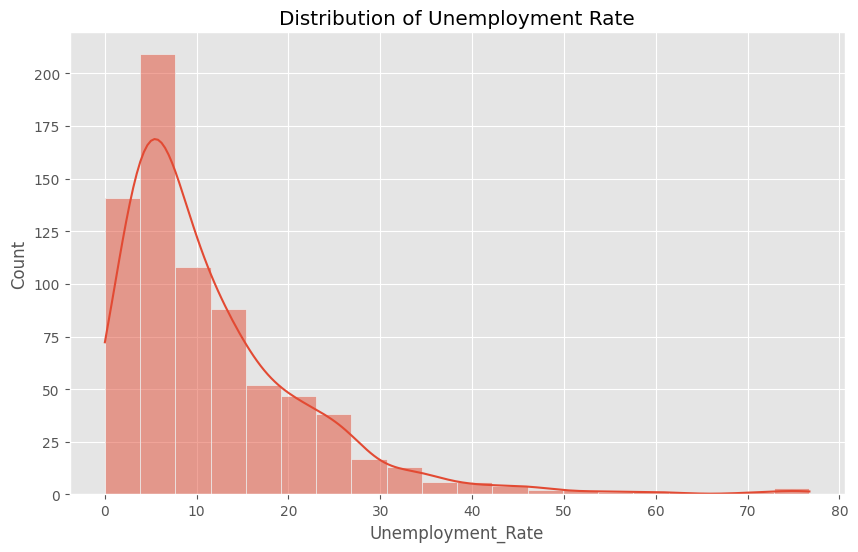

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(df['Unemployment_Rate'],
             bins=20,
             kde=True)

plt.title("Distribution of Unemployment Rate")
plt.show()

Step 10: State-wise Average Unemployment Rate

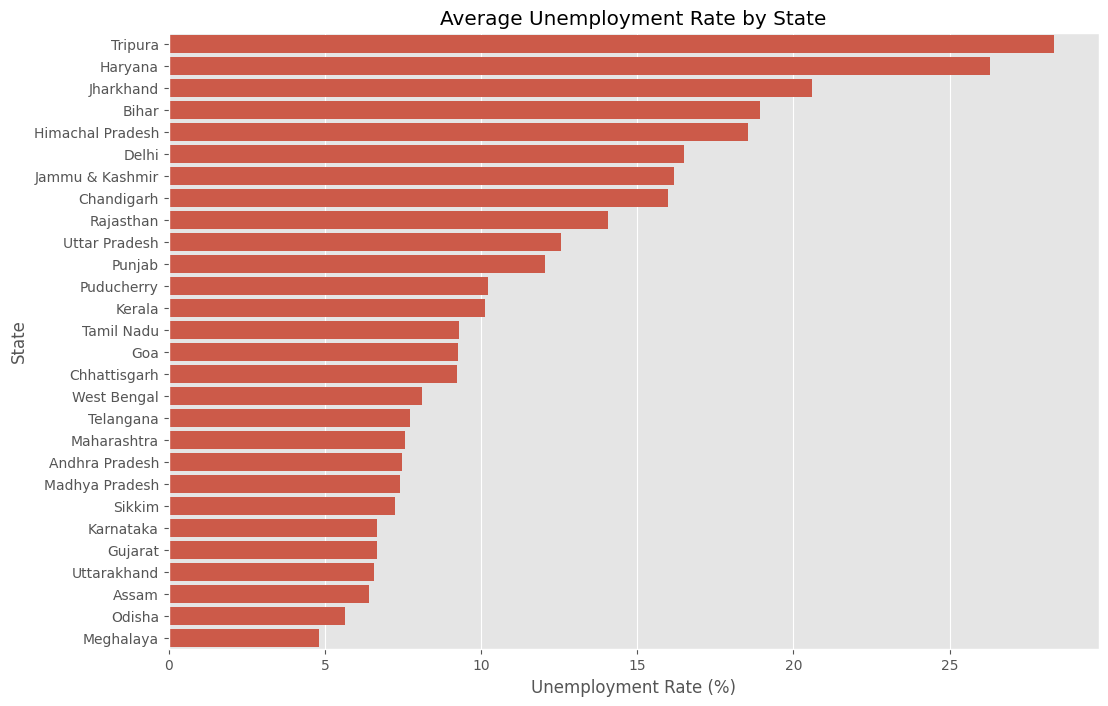

In [12]:
state_unemployment = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")

plt.show()

Step 11: Top 10 Highest Unemployment States

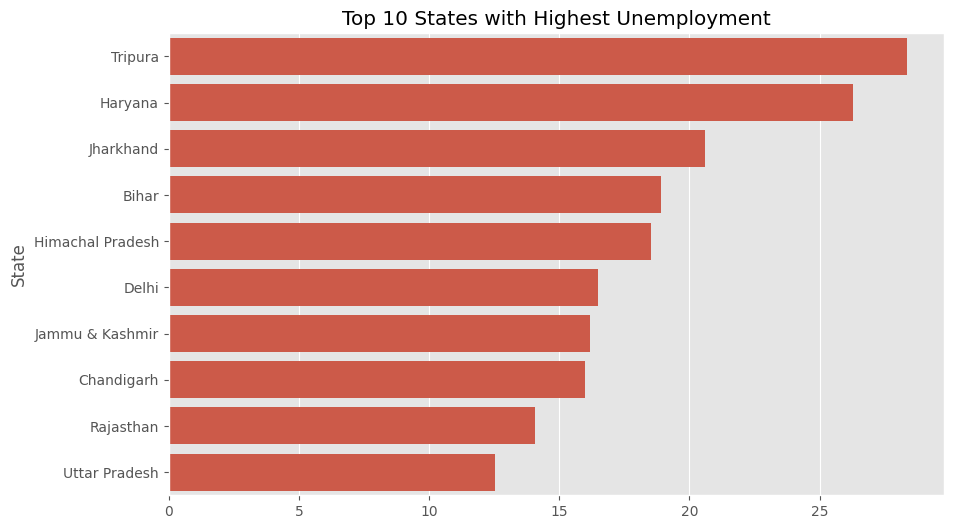

In [13]:
top10 = state_unemployment.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States with Highest Unemployment")
plt.show()

Step 12: Monthly Unemployment Trend

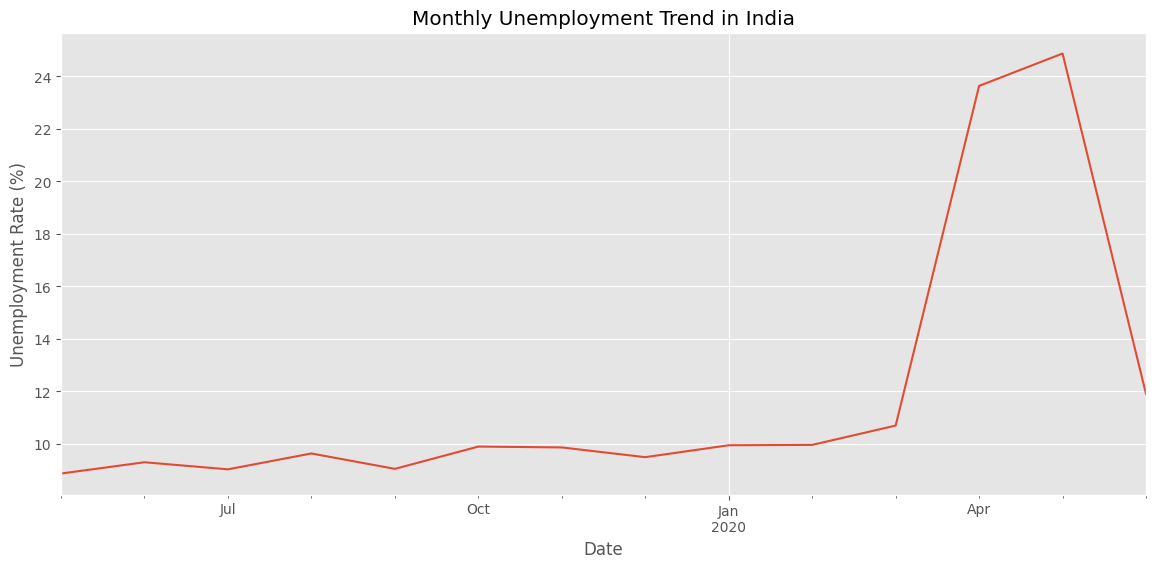

In [14]:
monthly = df.groupby('Date')['Unemployment_Rate'].mean()

plt.figure(figsize=(14,6))

monthly.plot()

plt.title("Monthly Unemployment Trend in India")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.show()

Step 13: Covid-19 Impact Analysis

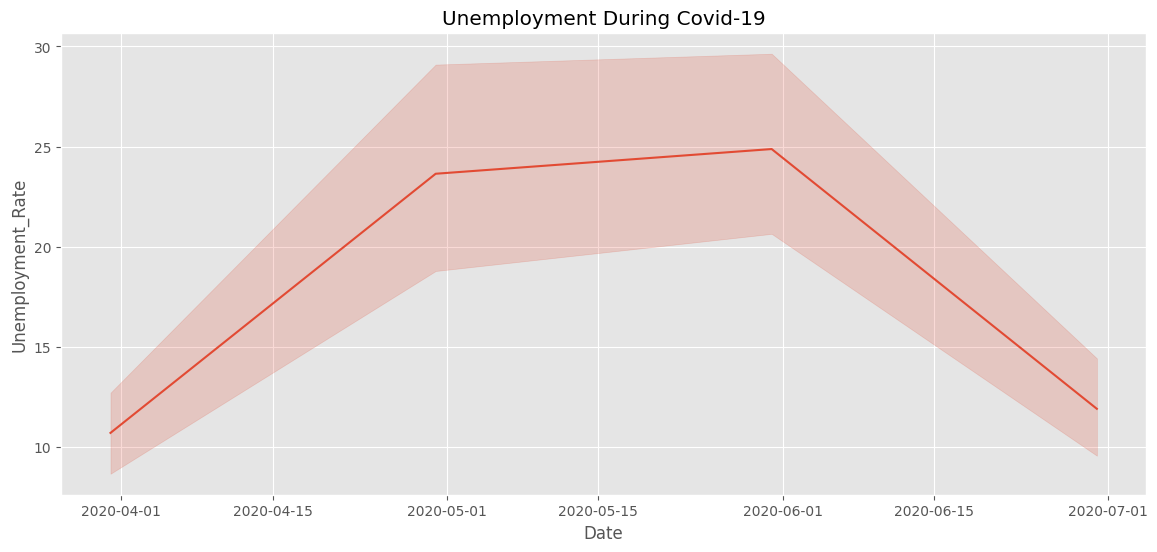

In [15]:
covid_data = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(14,6))

sns.lineplot(
    data=covid_data,
    x='Date',
    y='Unemployment_Rate'
)

plt.title("Unemployment During Covid-19")

plt.show()

Step 14: Labour Participation Rate Analysis

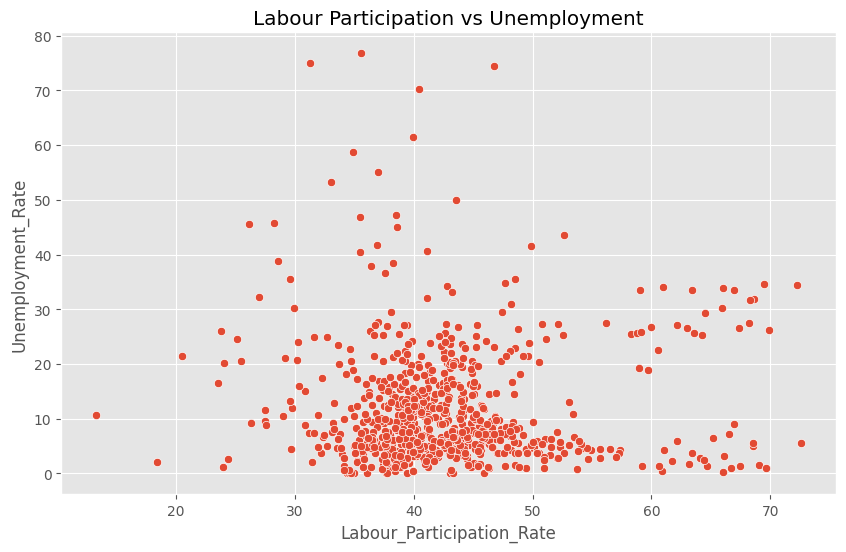

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Labour_Participation_Rate',
    y='Unemployment_Rate'
)

plt.title("Labour Participation vs Unemployment")

plt.show()

Step 15: Employment Distribution

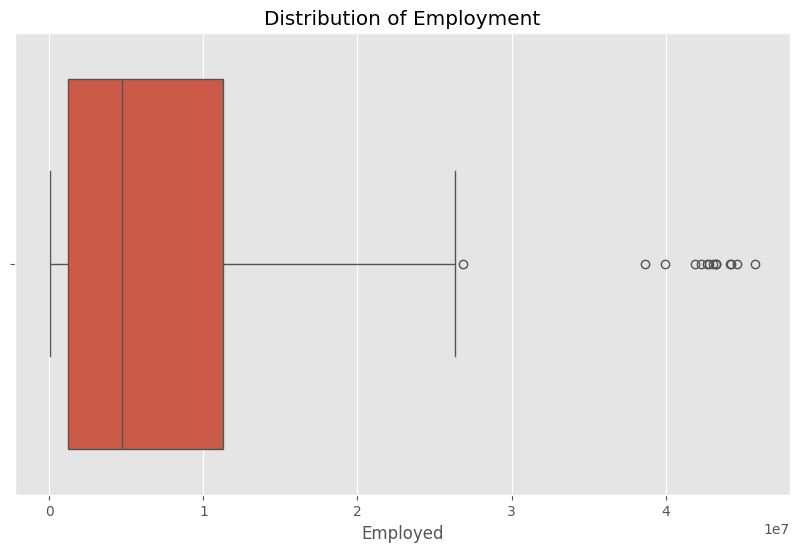

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Employed']
)

plt.title("Distribution of Employment")

plt.show()

Step 16: Correlation Heatmap

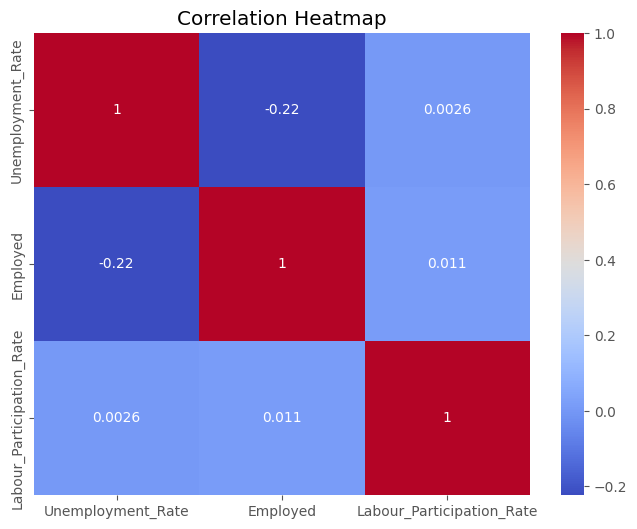

In [18]:
numeric_cols = [
    'Unemployment_Rate',
    'Employed',
    'Labour_Participation_Rate'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Step 17: State-wise Heatmap

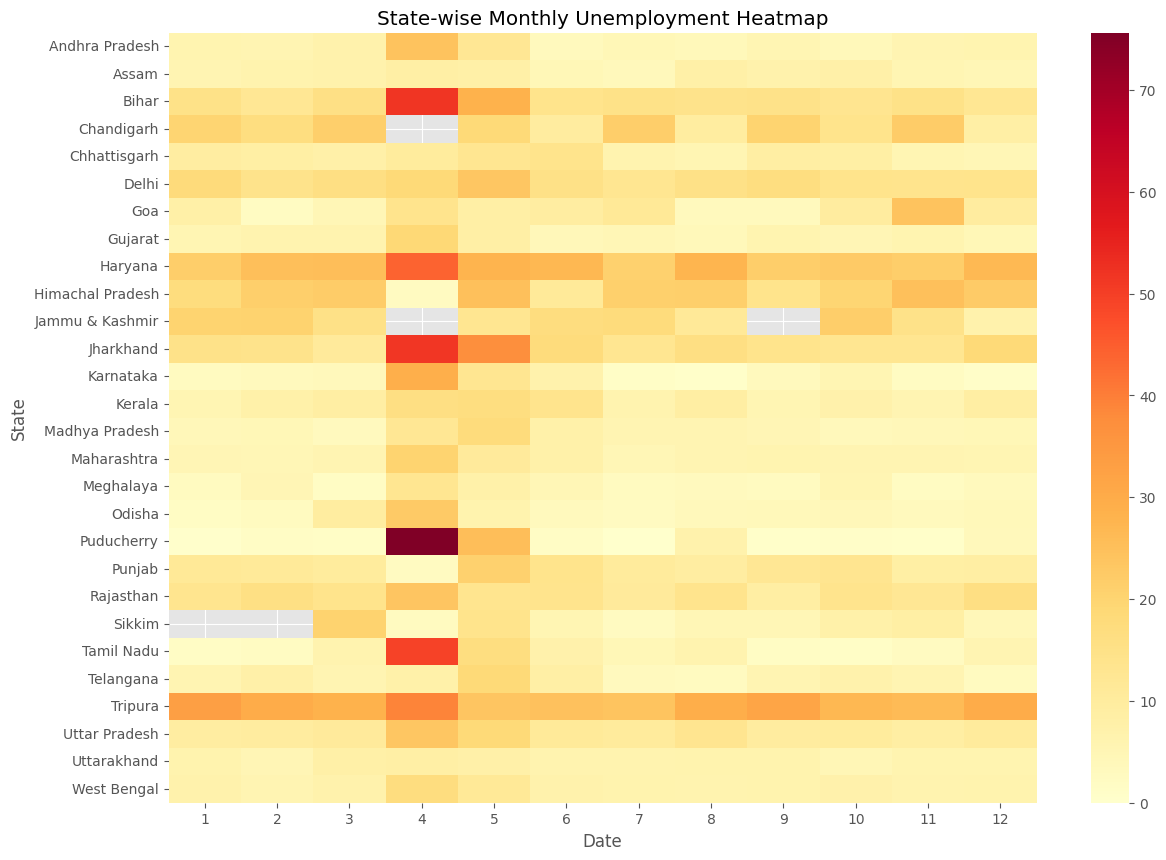

In [19]:
pivot = df.pivot_table(
    values='Unemployment_Rate',
    index='State',
    columns=df['Date'].dt.month,
    aggfunc='mean'
)

plt.figure(figsize=(14,10))

sns.heatmap(
    pivot,
    cmap='YlOrRd'
)

plt.title("State-wise Monthly Unemployment Heatmap")

plt.show()

Step 18: Top 5 States Trend

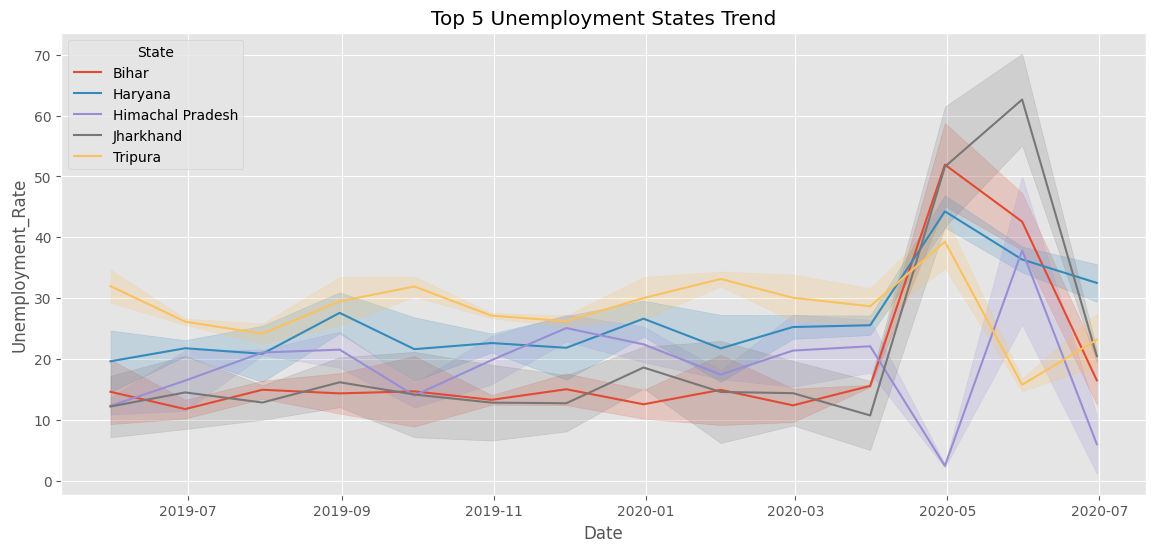

In [20]:
top_states = state_unemployment.head(5).index

top_df = df[df['State'].isin(top_states)]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=top_df,
    x='Date',
    y='Unemployment_Rate',
    hue='State'
)

plt.title("Top 5 Unemployment States Trend")

plt.show()

Step 19: Key Insights

In [21]:
print("Highest Unemployment State:")
print(state_unemployment.idxmax())

print("\nLowest Unemployment State:")
print(state_unemployment.idxmin())

print("\nAverage Unemployment Rate:")
print(round(df['Unemployment_Rate'].mean(),2), "%")

Highest Unemployment State:
Tripura

Lowest Unemployment State:
Meghalaya

Average Unemployment Rate:
11.79 %


Step 20: Save Cleaned Dataset

In [22]:
df.to_csv("Cleaned_Unemployment_Data.csv", index=False)

print("Saved Successfully")

Saved Successfully
